<a href="https://colab.research.google.com/github/Jules-Vatel/SSI_SPRING/blob/main/SSI_SPRING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/Jules-Vatel/SSI_SPRING/refs/heads/main/Offer-Westort_April%2028%2C%202026_08.08.csv"
df = pd.read_csv(url)


In [ ]:
#function for seven point party Id.
def seven_pt_pid(row):
  party = row['Q-PartyAffiliation']
  strength = row['Q-PolarAffiliation']
  lean = row['Q-MiddleAffiliation']
  if (party=='Democrat'):
      return 1 if strength == 'Strong' else 2
  elif(party=='Republican'):
      return 7 if strength == 'Strong' else 6
  elif(party in ['Independent','No Preference','Other Party (Please Specify)']):
      if (lean=='Closer to Democratic Party'):
          return 3
      elif (lean=='Closer to Republican Party'):
          return 5
      elif(lean=='Neither'):
          return 4
  return np.nan



In [ ]:
# function that gets party for leaners too
def get_party(row):
    pa = row['Q-PartyAffiliation']
    if(pa=='Democrat'):
        return 'Democrat'
    elif(pa=='Republican'):
        return 'Republican'
    elif(pa in ['Independent','No Preference','Other Party (Please Specify)']):
        ma = row.get('Q-MiddleAffiliation', np.nan)
        if(ma=='Closer to Democratic Party'):
            return 'Democrat'
        elif(ma=='Closer to Republican Party'):
            return 'Republican'
    return np.nan




In [ ]:
def get_party_group(row):
    party = row['Q-PartyAffiliation']
    if party == 'Democrat':
        return 'Democrat'
    if party == 'Republican':
        return 'Republican'
    if party in ['Independent', 'No Preference', 'Other Party (Please Specify)']:
        return 'Independent'
    return np.nan

In [ ]:
#tuple used to map the questions evaluating how comfortable respondents were to certain policies,
#relates to the social distance, close freinds distance, and inlaw distance questions,
#used to quantize each of the values

comfort_map = {
    'Very uncomfortable': 1, 'Uncomfortable': 2, 'Somewhat uncomfortable': 3,
    'Neither comfortable nor uncomfortable': 4, 'Somewhat comfortable': 5,
    'Comfortable': 6, 'Very comfortable': 7, 'Very Comfortable': 7
}

#same thing as comfort map but relates to the relection question so it can be mapped to varaibles
reelect_map = {
    'Very unlikely': 1, 'Unlikely': 2, 'Somewhat unlikely': 3,
    'Neither likely nor unlikely': 4, 'Somewhat likely': 5,
    'Likely': 6, 'Very likely': 7
}
treatment_labels = {
    'T1': 'In-party electoral',
    'T2': 'In-party democracy',
    'T3': 'In-party policy',
    'T4': 'Out-party electoral',
    'T5': 'Out-party democracy',
    'T6': 'Out-party policy',
}

In [ ]:

#made a class to navigate the data better
#have access to each individual model,a 2d array containing all the models in a 2d array
# the class also has funciton that print the results from the regression direclty, I will add plotting functions and some other functions
#parameters to the constructor are a comfort_map for the social distance ,close freinds distance, inlaw distace questions and
# the relect map for the Q-ReElection column
#affective polarization measured by first applying the comfort map to the collumns in question, these are added to a filler column with a _n added to the name
#example row#1 has temporary row row#1_n. Then the mean score of the three is taken and subtracted by 8 to get the Post treatment outcome varialbe.

def run_ols(formula,data):
  return sm.OLS.from_formula(formula,data).fit(cov_type='HC1')


def _linear_estimate(model, weights):
  params = model.params
  cov = model.cov_params()
  estimate = sum(weight * params[name] for name, weight in weights.items())
  variance = 0
  for left_name, left_weight in weights.items():
    for right_name, right_weight in weights.items():
      variance += left_weight * right_weight * cov.loc[left_name, right_name]
  se = np.sqrt(variance)
  return estimate, se, estimate - 1.96 * se, estimate + 1.96 * se

class DATA_ANALYSIS:
  def __init__(self,df=df,cmap=comfort_map,rmap=reelect_map):
    df = df[~df['Treat_Party'].str.contains('ImportId',na=False)].copy()
    df['Feeling_ThermR'] = pd.to_numeric(df['Q-FeelingThermR_1'], errors='coerce')
    df['Feeling_ThermD'] = pd.to_numeric(df['Q-FeelingThermD_1'], errors='coerce')
    df['PA']=df.apply(seven_pt_pid,axis=1)
    df['Party'] = df.apply(get_party, axis=1)
    df['PartyGroup'] = df.apply(get_party_group, axis=1)
    # The plan defines APpre as |FTRep - FTDem| for every respondent.
    df['APpre'] = (df['Feeling_ThermR'] - df['Feeling_ThermD']).abs()
    for col in ['Q-InLawDist', 'Q-CloseFriendDist', 'Q-Social Distance 3']:
      df[col + '_n'] = df[col].map(cmap)
    # Additive social-distance index from the plan: sum of three 1-7 items divided by 18.
    df['APpost'] = df[['Q-InLawDist_n', 'Q-CloseFriendDist_n','Q-Social Distance 3_n']].sum(axis=1, min_count=3) / 18
    df['TB'] = df['Q-ReElection'].map(rmap)
    df['T1'] = ((df['Treat_Party'] == 'InParty') & (df['Treat_Frame'] == 'Electoral')).astype(int)
    df['T2'] = ((df['Treat_Party'] == 'InParty') & (df['Treat_Frame'] == 'Democracy')).astype(int)
    df['T3'] = ((df['Treat_Party'] == 'InParty') & (df['Treat_Frame'] == 'Policy')).astype(int)
    df['T4'] = ((df['Treat_Party'] == 'OutParty') & (df['Treat_Frame'] == 'Electoral')).astype(int)
    df['T5'] = ((df['Treat_Party'] == 'OutParty') & (df['Treat_Frame'] == 'Democracy')).astype(int)
    df['T6'] = ((df['Treat_Party'] == 'OutParty') & (df['Treat_Frame'] == 'Policy')).astype(int)

    analysis_vars = ['APpost','TB','APpre']
    full = df.dropna(subset=analysis_vars).copy()
    AP = run_ols('APpost ~ T1 + T2 + T3 + T4 + T5 + T6 + APpre', full)
    TB = run_ols('TB ~ T1 + T2 + T3 + T4 + T5 + T6 + APpre', full)
    self.df = df
    self.full = full
    self.AP = AP
    self.TB = TB
    self.f1_AP=f1_AP = AP.f_test('T1 + T2 + T3 + T4 + T5 + T6 = 0')
    self.f1_TB=f1_TB = TB.f_test('T1 + T2 + T3 + T4 + T5 + T6 = 0')
    self.f2_AP=f2_AP = AP.f_test('T1 + T2 + T3 = T4 + T5 + T6')
    self.f2_TB=f2_TB = TB.f_test('T1 + T2 + T3 = T4 + T5 + T6')
    self.f3_AP_EP=f3_AP_EP = AP.f_test('T1 + T4 = T3 + T6')
    self.f3_AP_DP=f3_AP_DP=AP.f_test('T2 + T5 = T3 + T6')
    self.f3_AP_ED=f3_AP_ED = AP.f_test('T1 + T4 = T2 + T5')
    self.f3_TB_EP=f3_TB_EP = TB.f_test('T1 + T4 = T3 + T6')
    self.f3_TB_DP=f3_TB_DP = TB.f_test('T2 + T5 = T3 + T6')
    self.f3_TB_ED=f3_TB_ED = TB.f_test('T1 + T4 = T2 + T5')
    self.f4_AP=f4_AP = AP.f_test('T1 - T3 = T4 - T6, T2 - T3 = T5 - T6')
    self.f4_TB=f4_TB = TB.f_test('T1 - T3 = T4 - T6, T2 - T3 = T5 - T6')
    self.model=[AP,TB]
    self.ftests=[[f1_AP,f1_TB],[f2_AP,f2_TB],[f3_AP_EP,f3_TB_EP,f3_AP_DP,f3_TB_DP,f3_AP_ED,f3_TB_ED],[f4_AP,f4_TB]]
    self.hte_models = self._run_party_group_models(full)
    self.samples_full = len(full)

  def _run_party_group_models(self, full):
    models = {}
    for group in ['Democrat', 'Independent', 'Republican']:
      group_data = full[full['PartyGroup'] == group].copy()
      if len(group_data) == 0:
        continue
      AP = run_ols('APpost ~ T1 + T2 + T3 + T4 + T5 + T6 + APpre', group_data)
      TB = run_ols('TB ~ T1 + T2 + T3 + T4 + T5 + T6 + APpre', group_data)
      models[group] = {
          'n': len(group_data),
          'AP': AP,
          'TB': TB,
          'Any treatment (AP)': AP.f_test('T1 + T2 + T3 + T4 + T5 + T6 = 0'),
          'Any treatment (TB)': TB.f_test('T1 + T2 + T3 + T4 + T5 + T6 = 0'),
          'In vs Out party (AP)': AP.f_test('T1 + T2 + T3 = T4 + T5 + T6'),
          'In vs Out party (TB)': TB.f_test('T1 + T2 + T3 = T4 + T5 + T6'),
      }
    return models

  def print_summary_all(self):
    labels=["Affective Polarization","Tolerance for Backsliding"]
    model = self.model
    for i in range(len(model)):
      print(f"Model Results ({labels[i]})")
      print(model[i].summary(),"\n")

  def print_summary_single(self,id):
    model = self.model

    n = None
    labels=["Affective Polarization","Tolerance for Backsliding"]
    if(id.upper()=="AP"):
      n = 0
    else:
      n = 1
    print(f"Results ({labels[n]})")
    print(model[n].summary(),"\n")

  def print_f_tests_all(self):
    ftests = self.ftests
    labels = [["RQ1: Any treatment (AP)","RQ1: Any treatment (TB)"],
      ["RQ2: In vs Out party (AP)","RQ2: In vs Out party (TB)"],
      ["RQ3: Electoral vs Policy (AP)","RQ3: Electoral vs Policy (TB)","RQ3: Democracy vs Policy (AP)","RQ3: Democracy vs Policy (TB)","RQ3: Electoral vs Democracy (AP)","RQ3: Electoral vs Democracy (TB)"],
      ["RQ4: Framing x Party (AP)","RQ4: Framing x Party (TB)"]]
    for i in range(len(ftests)):
      for j in range(len(ftests[i])):
        print(f"{labels[i][j]} {ftests[i][j]}")

  def print_hte_tests_all(self):
    for group, results in self.hte_models.items():
      print(f"\nParty group: {group} (n={results['n']})")
      for label in [
          'Any treatment (AP)',
          'Any treatment (TB)',
          'In vs Out party (AP)',
          'In vs Out party (TB)',
      ]:
        print(f"{label} {results[label]}")

  def _get_model(self, outcome):
    if outcome.upper() == 'AP':
      return self.AP, 'Affective Polarization'
    if outcome.upper() == 'TB':
      return self.TB, 'Tolerance for Backsliding'
    raise ValueError("outcome must be 'AP' or 'TB'")

  def _coefficient_table(self, model):
    ci = model.conf_int(alpha=0.05)
    rows = []
    for term in treatment_labels:
      rows.append({
          'term': term,
          'label': treatment_labels[term],
          'estimate': model.params[term],
          'lower': ci.loc[term, 0],
          'upper': ci.loc[term, 1],
      })
    return pd.DataFrame(rows)

  def plot_treatment_effects(self, outcome='AP', ax=None, save_path=None, show=True):
    model, title = self._get_model(outcome)
    plot_data = self._coefficient_table(model)
    if ax is None:
      fig, ax = plt.subplots(figsize=(8, 4.8))
    else:
      fig = ax.figure

    y = np.arange(len(plot_data))
    xerr = [
        plot_data['estimate'] - plot_data['lower'],
        plot_data['upper'] - plot_data['estimate'],
    ]
    ax.errorbar(plot_data['estimate'], y, xerr=xerr, fmt='o', capsize=4)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data['label'])
    ax.invert_yaxis()
    ax.set_xlabel('Treatment effect relative to control')
    ax.set_title(f'{title}: treatment-cell coefficients')
    fig.tight_layout()

    if save_path:
      fig.savefig(save_path, dpi=300, bbox_inches='tight')
    if show:
      plt.show()
    return fig, ax

  def graph_delta_ap(self, ax=None, save_path=None, show=True):
    return self.plot_treatment_effects(outcome='AP', ax=ax, save_path=save_path, show=show)

  def graph_delta_tb(self, ax=None, save_path=None, show=True):
    return self.plot_treatment_effects(outcome='TB', ax=ax, save_path=save_path, show=show)

  def plot_hte_in_vs_out(self, outcome='AP', ax=None, save_path=None, show=True):
    outcome_key = outcome.upper()
    if outcome_key not in ['AP', 'TB']:
      raise ValueError("outcome must be 'AP' or 'TB'")

    rows = []
    weights = {
        'T1': 1 / 3, 'T2': 1 / 3, 'T3': 1 / 3,
        'T4': -1 / 3, 'T5': -1 / 3, 'T6': -1 / 3,
    }
    for group, results in self.hte_models.items():
      estimate, se, lower, upper = _linear_estimate(results[outcome_key], weights)
      rows.append({
          'group': group,
          'estimate': estimate,
          'se': se,
          'lower': lower,
          'upper': upper,
      })

    plot_data = pd.DataFrame(rows)
    if ax is None:
      fig, ax = plt.subplots(figsize=(7, 3.8))
    else:
      fig = ax.figure

    y = np.arange(len(plot_data))
    xerr = [
        plot_data['estimate'] - plot_data['lower'],
        plot_data['upper'] - plot_data['estimate'],
    ]
    ax.errorbar(plot_data['estimate'], y, xerr=xerr, fmt='o', capsize=4)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data['group'])
    ax.invert_yaxis()
    ax.set_xlabel('Average in-party effect minus average out-party effect')
    ax.set_title(f'{self._get_model(outcome_key)[1]}: HTE by party group')
    fig.tight_layout()

    if save_path:
      fig.savefig(save_path, dpi=300, bbox_inches='tight')
    if show:
      plt.show()
    return fig, ax


Model Results (Affective Polarization)
                            OLS Regression Results                            
Dep. Variable:                 APpost   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                     1.249
Date:                Sat, 02 May 2026   Prob (F-statistic):              0.285
Time:                        02:43:10   Log-Likelihood:                 63.919
No. Observations:                  97   AIC:                            -111.8
Df Residuals:                      89   BIC:                            -91.24
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    

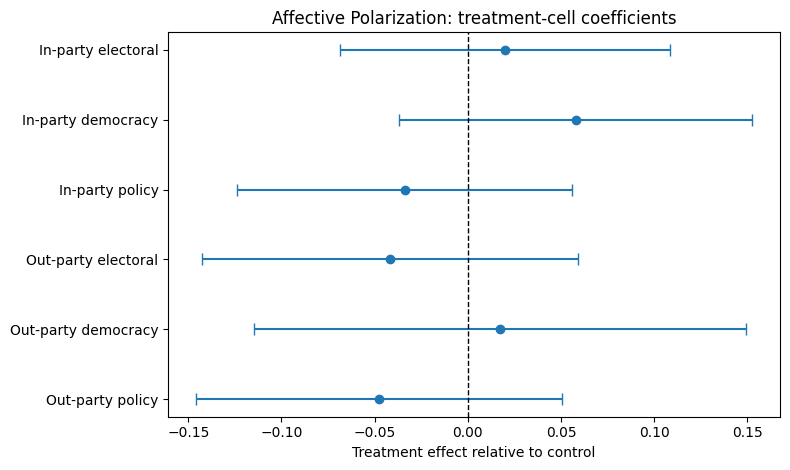

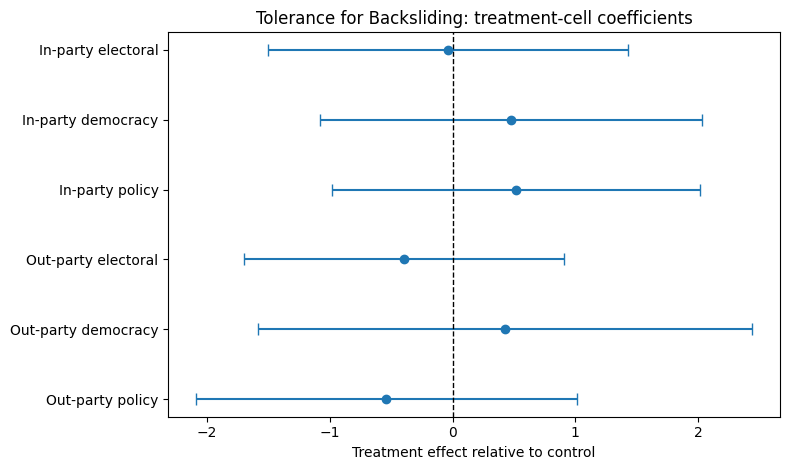

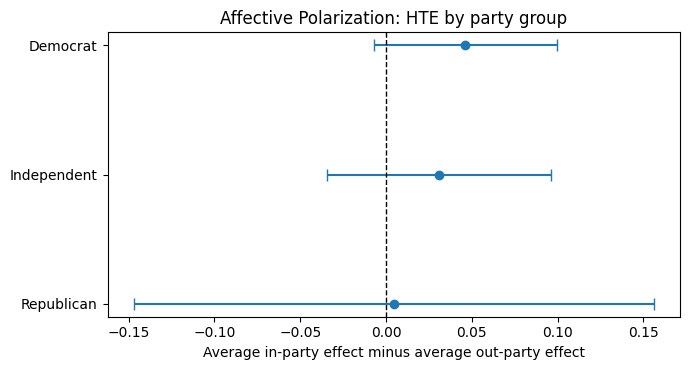

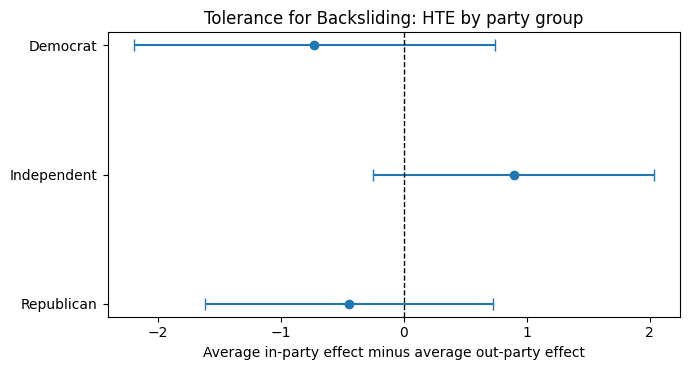

(<Figure size 700x380 with 1 Axes>,
 <Axes: title={'center': 'Tolerance for Backsliding: HTE by party group'}, xlabel='Average in-party effect minus average out-party effect'>)

In [ ]:

  results = DATA_ANALYSIS()
  #results.print_summary_single("AP")
  results.print_summary_all()

  results.print_f_tests_all()
  results.print_hte_tests_all()

  results.graph_delta_ap()
  results.graph_delta_tb()
  results.plot_hte_in_vs_out('AP')
  results.plot_hte_in_vs_out('TB')




In [ ]:
results.print_f_tests_all()

RQ1: Any treatment (AP) <F test: F=0.014256579069317927, p=0.9052268414959144, df_denom=89, df_num=1>
RQ1: Any treatment (TB) <F test: F=0.01617216722600125, p=0.8990928612768854, df_denom=89, df_num=1>
RQ2: In vs Out party (AP) <F test: F=1.6261415678133595, p=0.20555631023709262, df_denom=89, df_num=1>
RQ2: In vs Out party (TB) <F test: F=0.9493033905211404, p=0.3325374488703394, df_denom=89, df_num=1>
RQ3: Electoral vs Policy (AP) <F test: F=0.9370039341278693, p=0.3356727164587493, df_denom=89, df_num=1>
RQ3: Electoral vs Policy (TB) <F test: F=0.1637485040697852, p=0.6866994491487108, df_denom=89, df_num=1>
RQ3: Democracy vs Policy (AP) <F test: F=4.1568046923400965, p=0.044434363626344134, df_denom=89, df_num=1>
RQ3: Democracy vs Policy (TB) <F test: F=0.4755823897081343, p=0.49222436852300755, df_denom=89, df_num=1>
RQ3: Electoral vs Democracy (AP) <F test: F=1.5293789959299398, p=0.21945915053809575, df_denom=89, df_num=1>
RQ3: Electoral vs Democracy (TB) <F test: F=1.126687659

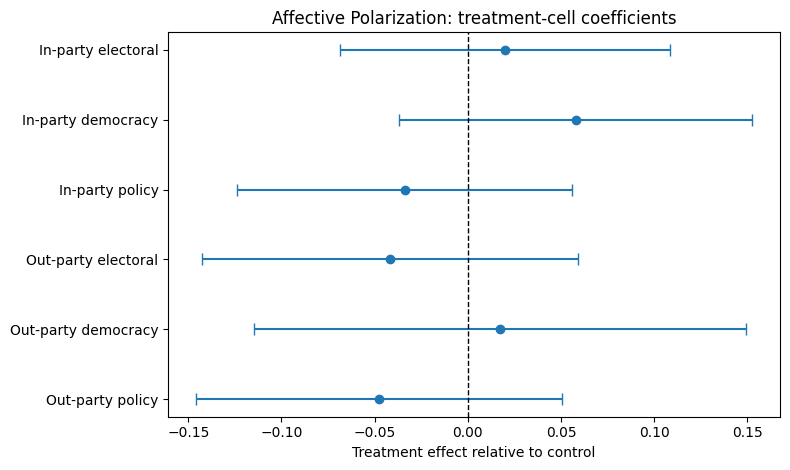

(<Figure size 800x480 with 1 Axes>,
 <Axes: title={'center': 'Affective Polarization: treatment-cell coefficients'}, xlabel='Treatment effect relative to control'>)

In [ ]:
results.graph_delta_ap()